In [99]:
using LaTeXStrings
using CSV
using StatsKit
using Plots
using LsqFit
using Odrpack
using Optim
using Images
using Colors
using FileIO

## Stabilità dell'intensità luminosa

In [100]:
#intensita_df = CSV.read("dati/allineamento/jpeg/allineamento_jpeg.csv", DataFrame)
intensita_df = CSV.read("dati/intensita/intensita.csv", DataFrame)

#delete!(intensita_df, [1,5,8,9,10])

intden_exp = intensita_df.IntDen

intensita_mean = mean(intensita_df.IntDen)
intensita_std = std(intensita_df.IntDen)

168257.72550280648

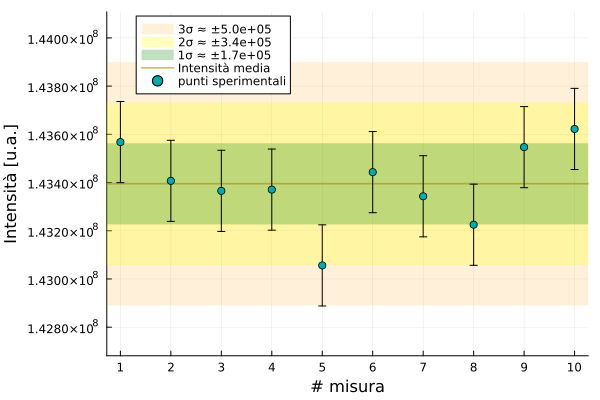

In [149]:
using Printf
p = plot()

colors = [:green, :yellow, :orange, :blue]
alphas = [0.25, 0.25, 0.15, 0.00]

for (i, (c, α)) in zip(colors, alphas) |> enumerate |> collect |> reverse
    lower = intensita_mean - i * intensita_std
    upper = intensita_mean + i * intensita_std

    label_text = i<4 ? "$(i)σ ≈ ±$(@sprintf("%0.1e", i*intensita_std))" : ""

    hline!(p, [lower], fillrange=upper, fillalpha=α, fillcolor=c, linealpha=0, label=label_text)
end

hline!(p, [intensita_mean], label="Intensità media", alpha=1)

scatter!(p, intensita_df.IntDen, yerr=intensita_std, label=("punti sperimentali"), legend=(0.15, 0.95), xticks=1:length(intensita_df.IntDen))
xlabel!(p, "# misura")
ylabel!(p, "Intensità [u.a.]")

savefig(p, "typst/grafici/intensita.svg")

plot(p)

## Calibrazione del primo polarizzatore

Il primo polarizzatore è montato su un supporto goniometrico che ne permette la rotazione precisa e la misura dell'angolo di orientazione. Poiché l'asse di trasmissione ottico del polarizzatore non è allineato con lo zero della scala angolare del goniometro, effettuiamo una procedura di calibrazione per determinare questa relazione angolare.

Misuriamo l'intensità luminosa $ I $ del fascio trasmesso in funzione dell'angolo $ \theta $ indicato dal goniometro in una serie di dati $ (\theta_i, I_i) $ a intervalli angolari regolari.

Il comportamento atteso è descritto dalla _legge di Malus_. Per tenere conto dello sfasamento strumentale e di eventuali offset sperimentali, utilizziamo il seguente modello
$$
I(\theta) = k I_0 \cdot \cos^2(\theta - \theta_{\text{offset}}) + I_{\text{offset}}
$$
dove $ I_0 $ è l'intensità luminosa del fascio in ingresso, e $ k $, $ \theta_{\text{offset}} $ e $ I_{\text{offset}} $ sono parametri determinati con il metodo dei minimi quadrati. 

In [102]:
# Il .csv ottenuto da ImageJ ha una colonna idiota che contiene il numero della misura.
# La sostituisco con una colonna "angolo".

angle = 120:10:220

calibrazione_p1_df = CSV.read("dati/calibrazione_p1/calibrazione_p1.csv", DataFrame)

DataFrames.rename!(calibrazione_p1_df, 1 => :Angle)  # Rinnomino
calibrazione_p1_df[!, 1] = angle  # Sostituisco

angle = calibrazione_p1_df.Angle
x_angle = 115:0.1:225
intden_exp = calibrazione_p1_df.IntDen

11-element Vector{Float64}:
 1.6408346e8
 1.99320277e8
 2.28650764e8
 2.50840336e8
 2.66381153e8
 2.76242978e8
 2.76765781e8
 2.70398811e8
 2.58071684e8
 2.36643589e8
 2.1088087e8

In [125]:
# Faccio il fit pesato con LsqFit.jl senza incertezze sull'angolo

w = [1/(intensita_std^2)]

# La legge di Malus
@. model(x, p) = p[1] * cos(x + p[2])^2 + p[3]

p0 = [1e8, π, 0]

fit = curve_fit(model, deg2rad.(angle), intden_exp, w, p0)

# Qualità del fit
resid = intden_exp .- model(deg2rad.(angle), fit.param)  # Perché fit.resid ritorna i residui PESATI

@show chisq_min = sum(w .* resid.^2)
@show df = length(intden_exp) - length(fit.param)
@show pvalue = ccdf(Chisq(df), chisq_min)
@show pvalue = ccdf(TDist(df), chisq_min)
@show critico = quantile(Chisq(df), 1 - 0.05)

chisq_min = sum(w .* resid .^ 2) = 3934.0039991516983
df = length(intden_exp) - length(fit.param) = 8
pvalue = ccdf(Chisq(df), chisq_min) = 0.0
pvalue = ccdf(TDist(df), chisq_min) = 9.76132656510591e-27
critico = quantile(Chisq(df), 1 - 0.05) = 15.50731305586545


15.50731305586545

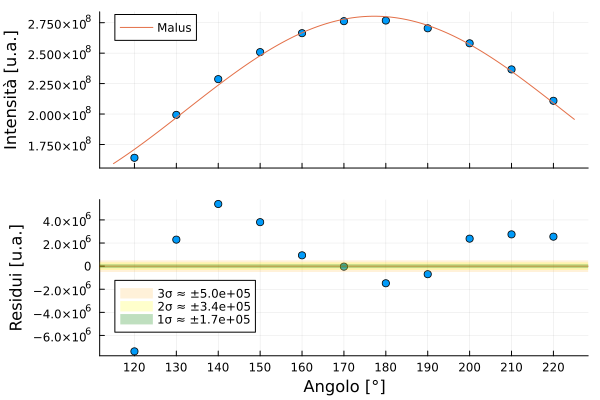

In [119]:
# Plotto i dati sperimentali, il fit e i residui

intden_th = model(deg2rad.(x_angle), fit.param)

p = scatter(angle, intden_exp, label="")
plot!(p, x_angle, intden_th, label="Malus")

q = scatter(angle, resid, label="")
hline!(q, [0], c=:red, alpha=0.5, label="")

for (i, (c, α)) in zip(colors, alphas) |> enumerate |> collect |> reverse
    lower = 0 - i * intensita_std
    upper = 0 + i * intensita_std

    label_text = i<4 ? "$(i)σ ≈ ±$(@sprintf("%0.1e", i*intensita_std))" : ""

    hline!(q, [lower], fillrange=upper, fillalpha=α, fillcolor=c, linealpha=0, label=label_text)
end

r = plot(p,
  q,
  layout=(2,1),
  link=:x,
  xlabel=["" "Angolo [°]"],
  ylabel=["Intensità [u.a.]" "Residui [u.a.]"],
  xticks=[(angle, []) (angle, angle)],
  legend=[(0.12, 0.9) (0.12,0.40)]
)

savefig(r, "typst/grafici/calibrazione_p1_residui.svg")

plot(r)

In [105]:
# Trovo il massimo

f = x -> -model(x[1], fit.param)[1]

res = optimize(f, [deg2rad(175)])

@show rad2deg.(Optim.minimizer(res))

rad2deg.(Optim.minimizer(res)) = [177.24321881096506]


1-element Vector{Float64}:
 177.24321881096506

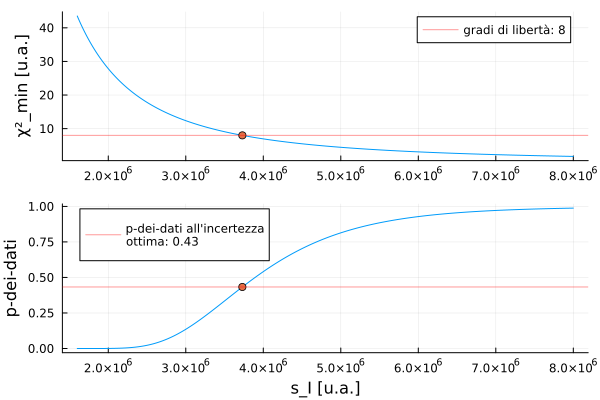

In [106]:
# Che incertezza avrei dovuto avere affinché il fit fosse buono?
# Plotto incertezze vs. chisq_min (o p-value) per scoprirlo.

istds = []
chisq_mins = []
pvalues = []

for istd in 1.6e6:10000:8e6
    push!(istds, istd)

    w = [1/(istd^2)]

    fit = curve_fit(model, deg2rad.(angle), intden_exp, w, p0)

    resid = intden_exp .- model(deg2rad.(angle), fit.param)
    chisq_min = sum(w .* resid.^2)
    pvalue = ccdf(Chisq(df), chisq_min)

    push!(chisq_mins, chisq_min)
    push!(pvalues, pvalue)
end


j0 = argmin(abs.(chisq_mins .- 8))  # Indice dove sta l'incertezza ottima
istd0 = istds[j0]  # Incertezza ottima
chisq_min0 = chisq_mins[j0]  #diocane
pvalue0 = pvalues[j0]


p = plot(istds, chisq_mins, label="")
scatter!(p, [istd0], [chisq_min0], label="")
hline!(p, [8], label="gradi di libertà: 8", c=:red, alpha=0.4)#l=:dash)
# hline!(p, [intensita_std], label="calcolata", c=:green, l=:dot)

q = plot(istds, pvalues, label="")
scatter!(q, [istd0], [pvalue0], label="")
hline!(q, [pvalue0], label="p-dei-dati all'incertezza\nottima: $(round(pvalue0, digits=2))", c=:red, alpha=0.4)#l=:dash)

r = plot(p, q, link=:x, layout=(2,1), xlabel=["" "s_I [u.a.]"], ylabel=["χ²_min [u.a.]" "p-dei-dati"])

savefig(r, "typst/grafici/chisq_mins.svg")

plot(r)


chisq_min = sol.sum_square = 555.2998549154713
df = length(intden_exp) - length(fit.param) = 8
pvalue = ccdf(Chisq(df), chisq_min) = 9.445196043663827e-115
pvalue = ccdf(TDist(df), chisq_min) = 6.19336941783557e-20
critico = quantile(Chisq(df), 1 - 0.05) = 15.50731305586545


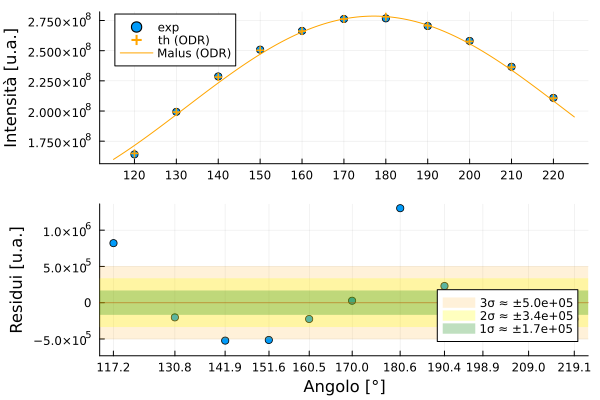

In [ ]:
# Faccio il fit pesato con ODRPACK con incertezze triangolari sull'angolo.
# Poi plotto dati sprimentali, fit e residui.

# Fit
function odr_model!(x, p, y)
    y .= p[1] .* cos.(x .+ p[2]).^2 .+ p[3]
    return nothing
end

sol = odr_fit(odr_model!, deg2rad.(angle), intden_exp, [1e8, 0, 0]; weight_x=1/(deg2rad(0.5)/sqrt(6))^2, weight_y=1/intensita_std^2)

# Qualità del fit
# intden_th = Vector{Float64}(undef, length(angle))
# odr_model!(deg2rad.(angle), sol.beta, intden_th)

# resid = intden_exp - intden_th

@show chisq_min = sol.sum_square  #sum(w .* resid.^2)
@show df = length(intden_exp) - length(fit.param)
@show pvalue = ccdf(Chisq(df), chisq_min)
@show pvalue = ccdf(TDist(df), chisq_min)
@show critico = quantile(Chisq(df), 1 - 0.05)

# Plotti
intden_th = Vector{Float64}(undef, length(x_angle))
odr_model!(deg2rad.(x_angle), sol.beta, intden_th)

p = plot()
scatter!(p, angle, intden_exp, label="exp", xticks=angle)
plot!(p, x_angle, intden_th, label="Malus (ODR)", c=:orange)
scatter!(p, angle, sol.yest, label="th (ODR)", m=:+, msw=2, c=:orange)


q = scatter(rad2deg.(sol.xplusd), sol.eps, label="", xticks=round.(rad2deg.(sol.xplusd), digits=1))
hline!(q, [0], c=:red, alpha=0.5, label="")

for (i, (c, α)) in zip(colors, alphas) |> enumerate |> collect |> reverse
    lower = 0 - i * intensita_std
    upper = 0 + i * intensita_std

    label_text = i<4 ? "$(i)σ ≈ ±$(@sprintf("%0.1e", i*intensita_std))" : ""

    hline!(q, [lower], fillrange=upper, fillalpha=α, fillcolor=c, linealpha=0, label=label_text)
end

r = plot(p,
  q,
  layout=(2,1),
  #link=:x,
  xlabel=["" "Angolo [°]"],
  ylabel=["Intensità [u.a.]" "Residui [u.a.]"],
  #xticks=[(angle, []) (angle, angle)],
  legend=[(0.12, 0.9) (0.78,0.35)]
)

savefig(r, "typst/grafici/calibrazione_p1_odr_residui.svg")

plot(r)

In [160]:
intden_th = similar(intden_exp)
odr_model!(deg2rad.(angle), sol.beta, intden_th)

resid = intden_exp - intden_th

11-element Vector{Float64}:
      -7.379016335939646e6
       2.293913579971552e6
       5.378833287783265e6
       3.8067605462533236e6
  935860.3957377076
  -43379.347406089306
      -1.4833962780795097e6
 -698196.3445063233
       2.3791792045381963e6
       2.7499090153947473e6
       2.55107709948346e6

In [162]:
-sol.eps

11-element Vector{Float64}:
 -820798.4078660309
  202749.24350368977
  522932.5671956539
  513878.7954002023
  225047.5451106429
  -26586.405628979206
      -1.3026562908142805e6
 -230008.0403587222
  395526.5532566309
  293066.8236311674
  226849.89554178715

# Calibrazione del secondo polarizzatore

Stesse considerazioni fatte per il primo polarizzatore.

In [137]:
index = 130:10:240

calibrazione_p2_df = CSV.read("dati/calibrazione_p2/calibrazione_p2.csv", DataFrame)

calibrazione_p2_df[!, 1] = index

DataFrames.rename!(calibrazione_p2_df, 1 => :Angle)

angle = calibrazione_p2_df.Angle
x_angle = 125:0.1:245
intden_exp = calibrazione_p2_df.IntDen


12-element Vector{Float64}:
 1.79707789e8
 2.05769405e8
 2.26916975e8
 2.40959428e8
 2.49735531e8
 2.50995853e8
 2.45167066e8
 2.33266251e8
 2.14690234e8
 1.90804163e8
 1.6163148e8
 1.29889009e8

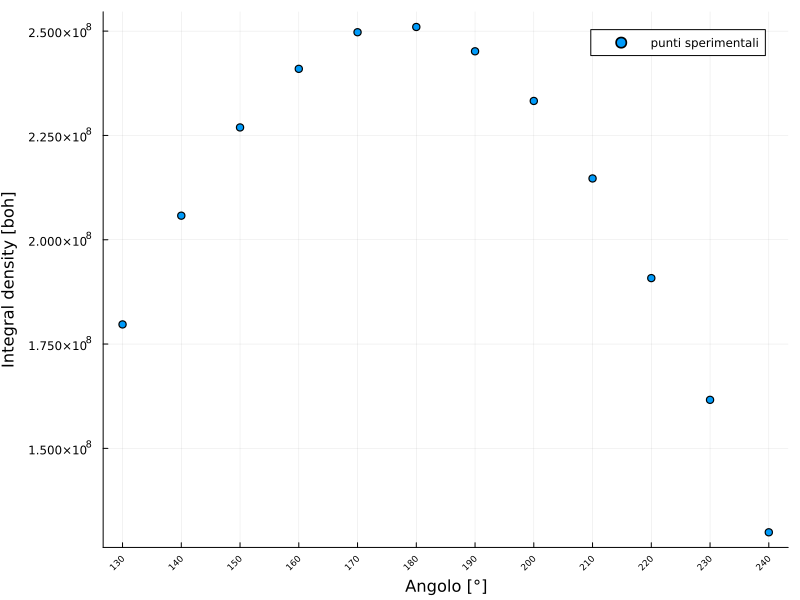

In [24]:
# Plotto i punti sperimentali

p = scatter(size=(800, 600), calibrazione_p2_df.Angle, calibrazione_p2_df.IntDen, label="punti sperimentali", xticks=calibrazione_p2_df.Angle, xrotation=45, xtickfontsize=6)
xlabel!("Angolo [°]")
ylabel!("Integral density [boh]")

rad2deg.((Optim.minimizer(res))[1]) = 176.53043544785834
plot(p, x_axis, model(deg2rad.(x_axis), fit.param), label = "A cos(θ + ϕ)^2 + b") = Plot{Plots.GRBackend() n=2}


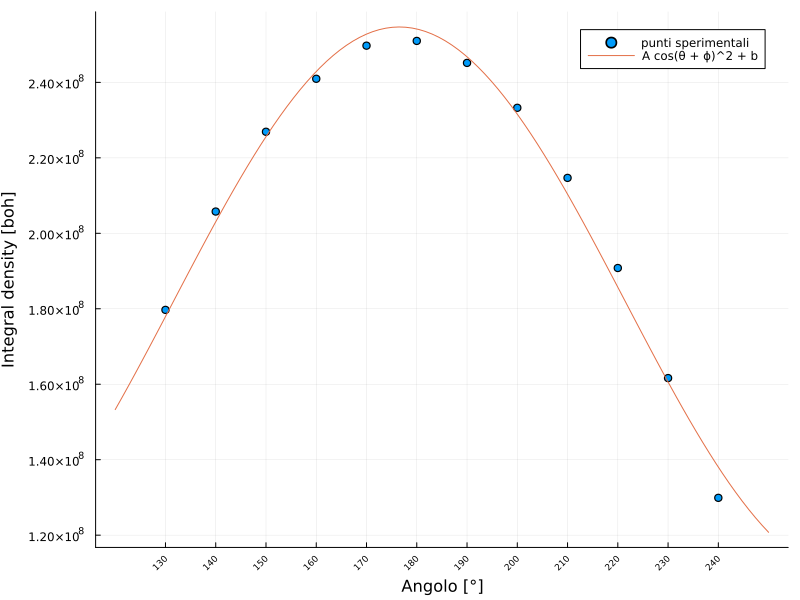

In [31]:
# Fitto i punti con Malus
using LsqFit

x_axis = range(120, 250, length=100)

@. model(x, p) = p[1] * cos(x + p[2])^2 + p[3]

p0 = [1e8, π, 0]

fit = curve_fit(model, deg2rad.(calibrazione_p2_df.Angle), calibrazione_p2_df.IntDen, p0)

# Trovo il massimo
using Optim

f = x -> -model(x[1], fit.param)[1]

res = optimize(f, [deg2rad(180)])

@show rad2deg.(Optim.minimizer(res)[1])


# Plotto la curva a tre parametri fittata
@show plot(p, x_axis, model(deg2rad.(x_axis), fit.param), label="A cos(θ + ϕ)^2 + b")

## Verifica della legge di Malus

In [43]:
index = -30:15:195

malus_df = CSV.read("malus/malus.csv", DataFrame)

malus_df[!, 1] = index

DataFrames.rename!(malus_df, 1 => :Angle)

Row,Angle,Area,Mean,Min,Max,IntDen,RawIntDen
,Int64,Int64,Float64,Int64,Int64,Float64,Float64
1,-30,1555200,124.015,0,454,1.92868e8,1.92868e8
2,-15,1555200,94.973,0,316,1.47702e8,1.47702e8
3,0,1555200,145.61,0,524,2.26453e8,2.26453e8
4,15,1555200,158.12,0,549,2.45908e8,2.45908e8
5,30,1555200,161.727,0,549,2.51518e8,2.51518e8
6,45,1555200,155.396,0,562,2.41671e8,2.41671e8
7,60,1555200,139.325,0,489,2.16678e8,2.16678e8
8,75,1555200,115.342,0,405,1.79379e8,1.79379e8
9,90,1555200,84.821,0,277,1.31914e8,1.31914e8


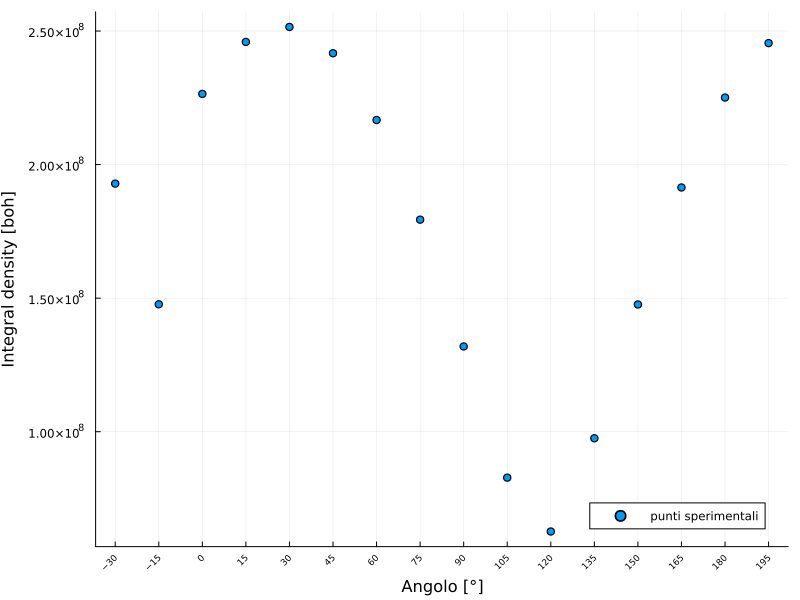

In [44]:
# Plotto i punti sperimentali

p = scatter(size=(800, 600), malus_df.Angle, malus_df.IntDen, label="punti sperimentali", xticks=malus_df.Angle, xrotation=45, xtickfontsize=6)
xlabel!("Angolo [°]")
ylabel!("Integral density [boh]")

rad2deg.((Optim.minimizer(res))[1]) = 117.02349220347358
plot(p, x_axis, model(deg2rad.(x_axis), fit.param), label = "A cos(θ + ϕ)^2 + b") = Plot{Plots.GRBackend() n=2}


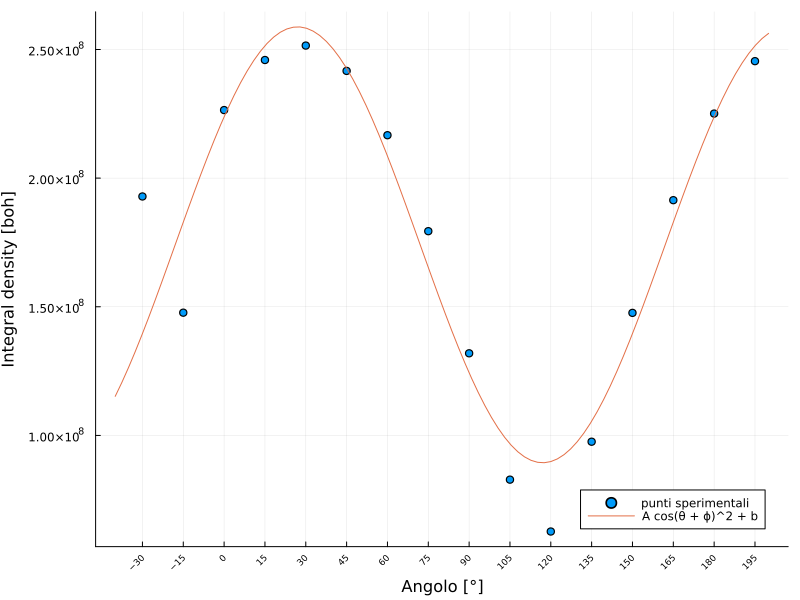

In [46]:
# Fitto i punti con Malus
using LsqFit

x_axis = range(-40, 200, length=100)

@. model(x, p) = p[1] * cos(x + p[2])^2 + p[3]

p0 = [1e8, π, 0]

fit = curve_fit(model, deg2rad.(malus_df.Angle), malus_df.IntDen, p0)

# Trovo il minimo
using Optim

f = x -> model(x[1], fit.param)[1]

res = optimize(f, [deg2rad(120)])

@show rad2deg.(Optim.minimizer(res)[1])


# Plotto la curva a tre parametri fittata
@show plot(p, x_axis, model(deg2rad.(x_axis), fit.param), label="A cos(θ + ϕ)^2 + b")

## Lamina $ \lambda / 2 $

In [47]:
index = 0:10:90

lambdamezzi_df = CSV.read("lambdamezzi/lambdamezzi.csv", DataFrame)

lambdamezzi_df[!, 1] = index

DataFrames.rename!(lambdamezzi_df, 1 => :Angle)

Row,Angle,Area,Mean,Min,Max,IntDen,RawIntDen
,Int64,Int64,Float64,Int64,Int64,Float64,Float64
1,0,1555200,118.571,0,445,1.84401e8,1.84401e8
2,10,1555200,147.752,0,549,2.29784e8,2.29784e8
3,20,1555200,160.076,0,593,2.4895e8,2.4895e8
4,30,1555200,155.287,0,577,2.41503e8,2.41503e8
5,40,1555200,133.973,0,462,2.08356e8,2.08356e8
6,50,1555200,98.519,0,330,1.53217e8,1.53217e8
7,60,1555200,56.594,0,205,8.80143e7,8.80143e7
8,70,1555200,42.185,0,205,6.5606e7,6.5606e7
9,80,1555200,79.897,0,265,1.24256e8,1.24256e8


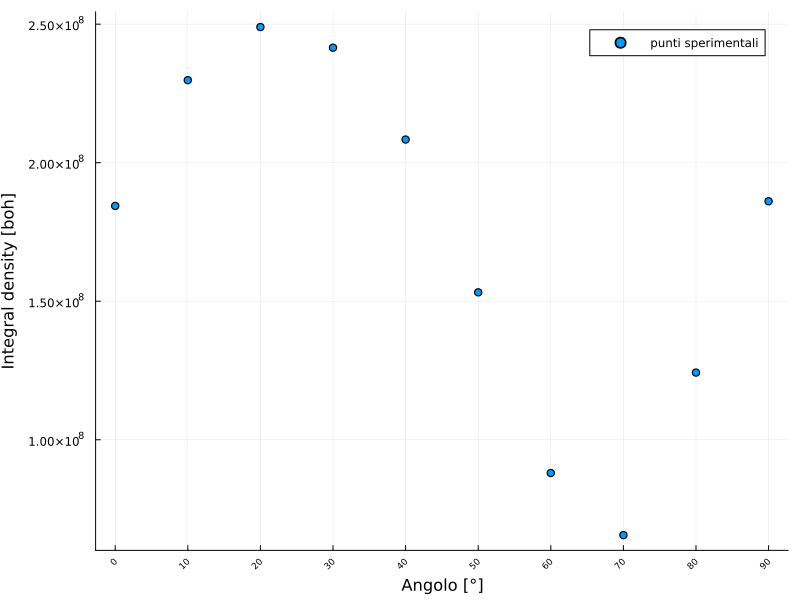

In [48]:
# Plotto i punti sperimentali

p = scatter(size=(800, 600), lambdamezzi_df.Angle, lambdamezzi_df.IntDen, label="punti sperimentali", xticks=lambdamezzi_df.Angle, xrotation=45, xtickfontsize=6)
xlabel!("Angolo [°]")
ylabel!("Integral density [boh]")

rad2deg.((Optim.minimizer(res))[1]) = 66.81832551678379
rad2deg.((Optim.minimizer(res))[1]) = 22.095032059768936
plot(p, x_axis, model(deg2rad.(x_axis), fit.param), label = "A cos(θ + ϕ)^2 + b") = Plot{Plots.GRBackend() n=2}


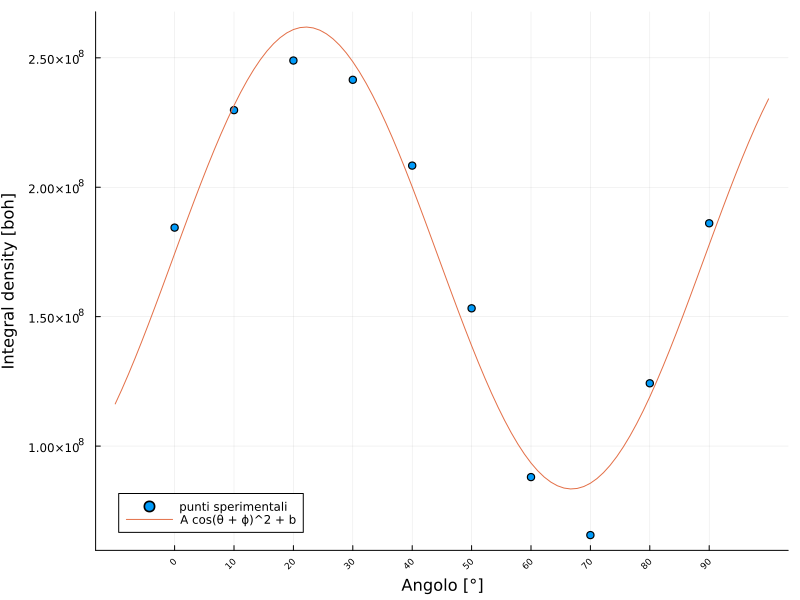

In [60]:
# Fitto i punti con Malus
using LsqFit

x_axis = range(-10, 100, length=100)

@. model(x, p) = p[1] * cos(p[4]*x + p[2])^2 + p[3]

p0 = [1e8, π/2, 0, 1]

fit = curve_fit(model, deg2rad.(lambdamezzi_df.Angle), lambdamezzi_df.IntDen, p0)

# Trovo il minimo
using Optim

f = x -> model(x[1], fit.param)[1]
res = optimize(f, [deg2rad(70)])
@show rad2deg.(Optim.minimizer(res)[1])

g = x -> -model(x[1], fit.param)[1]
res = optimize(g, [deg2rad(20)])
@show rad2deg.(Optim.minimizer(res)[1])


# Plotto la curva a tre parametri fittata
@show plot(p, x_axis, model(deg2rad.(x_axis), fit.param), label="A cos(θ + ϕ)^2 + b")

In [55]:
fit.param

4-element Vector{Float64}:
 1.784599319411056e8
 2.365558657899553
 8.342810566315365e7
 2.0123741789573852